The Radius Valley graph for the number of planets vs the planet radii. \
Next step would include number of planets per star vs the planet radii

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('PS_2025.05.14_04.19.24.csv', sep=',')

In [ ]:
print(df.columns)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

Next thing to do is to check into multiplanetary systems. What do systems have in common to each other??

In [ ]:
print(df.shape)

(38430, 92)


In [ ]:
print(df.head(5))
print(df.tail(5))

    pl_name hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0  11 Com b   11 Com             0        2        1  Radial Velocity   
1  11 Com b   11 Com             0        2        1  Radial Velocity   
2  11 Com b   11 Com             1        2        1  Radial Velocity   
3  11 UMi b   11 UMi             1        1        1  Radial Velocity   
4  11 UMi b   11 UMi             0        1        1  Radial Velocity   

   disc_year                           disc_facility              soltype  \
0       2007                        Xinglong Station  Published Confirmed   
1       2007                        Xinglong Station  Published Confirmed   
2       2007                        Xinglong Station  Published Confirmed   
3       2009  Thueringer Landessternwarte Tautenburg  Published Confirmed   
4       2009  Thueringer Landessternwarte Tautenburg  Published Confirmed   

   pl_controv_flag  ... sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  \
0                0  ... 

In [ ]:
df.describe()

,default_flag,sy_snum,sy_pnum,disc_year,pl_controv_flag,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
count,38430.000000,38430.000000,38430.000000,38430.000000,38430.000000,3.523500e+04,3.368900e+04,3.368800e+04,35235.000000,21631.000000,...,36738.000000,37696.000000,37683.000000,37682.000000,37683.000000,37442.000000,37442.000000,37394.000000,37394.000000,37394.000000
mean,0.153344,1.085090,1.911475,2015.460630,0.002134,1.239533e+04,1.430814e+04,-3.370236e+03,-0.000199,4.679302,...,-36.624770,13.590266,0.116513,-0.117109,11.573205,0.035633,-0.035144,13.357505,0.000518,-0.000518
std,0.360323,0.309274,1.222313,3.914734,0.046144,2.142847e+06,2.560856e+06,5.460876e+05,0.020632,182.202423,...,173.397834,2.403740,0.149813,0.179552,2.310322,0.200508,0.192441,2.342123,0.001082,0.001082
min,0.000000,1.000000,1.000000,1992.000000,0.000000,9.070629e-02,0.000000e+00,-1.000000e+08,-1.000000,0.004400,...,-2900.000000,0.872000,0.001000,-12.270000,-3.044000,0.011000,-11.140000,2.364310,0.000118,-0.063232
25%,0.000000,1.000000,1.000000,2014.000000,0.000000,4.417459e+00,8.030000e-06,-1.990000e-04,0.000000,0.054500,...,-21.035750,12.598000,0.046000,-0.137000,10.756000,0.020000,-0.034000,12.401300,0.000253,-0.000506
50%,0.000000,1.000000,1.000000,2016.000000,0.000000,1.035585e+01,3.800000e-05,-3.801000e-05,0.000000,0.100430,...,-7.692000,14.163000,0.092000,-0.092000,12.256000,0.024000,-0.024000,13.983300,0.000352,-0.000352
75%,0.000000,1.000000,3.000000,2016.000000,0.000000,2.667396e+01,1.991000e-04,-8.060000e-06,0.000000,0.215800,...,-2.235000,15.264000,0.137000,-0.046000,13.160000,0.034000,-0.020000,15.034100,0.000506,-0.000253
max,1.000000,4.000000,8.000000,2025.000000,1.000000,4.020000e+08,4.700000e+08,0.000000e+00,1.000000,19000.000000,...,2700.000000,45.340000,11.000000,-0.001000,35.330000,9.995000,-0.011000,20.186100,0.063232,-0.000118


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38430 entries, 0 to 38429
Data columns (total 92 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          38430 non-null  object 
 1   hostname         38430 non-null  object 
 2   default_flag     38430 non-null  int64  
 3   sy_snum          38430 non-null  int64  
 4   sy_pnum          38430 non-null  int64  
 5   discoverymethod  38430 non-null  object 
 6   disc_year        38430 non-null  int64  
 7   disc_facility    38430 non-null  object 
 8   soltype          38430 non-null  object 
 9   pl_controv_flag  38430 non-null  int64  
 10  pl_refname       38430 non-null  object 
 11  pl_orbper        35235 non-null  float64
 12  pl_orbpererr1    33689 non-null  float64
 13  pl_orbpererr2    33688 non-null  float64
 14  pl_orbperlim     35235 non-null  float64
 15  pl_orbsmax       21631 non-null  float64
 16  pl_orbsmaxerr1   7167 non-null   float64
 17  pl_orbsmaxer

In [ ]:
df['pl_rade'].describe()

,pl_rade
count,26511.000000
mean,5.434876
std,72.573082
min,0.270000
25%,1.550000
50%,2.290000
75%,3.230000
max,4282.980000


In [ ]:
df.isnull().sum()

,0
pl_name,0
hostname,0
default_flag,0
sy_snum,0
sy_pnum,0
...,...
sy_gaiamagerr1,1036
sy_gaiamagerr2,1036
rowupdate,1
pl_pubdate,0


In [ ]:
star_count = df['hostname'].value_counts()
star_count

,count
hostname,
Kepler-11,103
Kepler-80,95
Kepler-32,86
KOI-351,77
Kepler-20,76
...,...
2MASS J03590986+2009361,1
2MASS J0249-0557 A,1
2MASS J02192210-3925225,1


In [ ]:
multi_planet_hosts = star_count[star_count > 1]
multi_planet_hosts

,count
hostname,
Kepler-11,103
Kepler-80,95
Kepler-32,86
KOI-351,77
Kepler-20,76
...,...
nu Oct A,2
kap And,2
2MASS J01225093-2439505,2


In [ ]:
Multiplanet_hosts = df['hostname'].value_counts().to_dict()
Multiplanet_hosts

{'Kepler-11': 103,
 'Kepler-80': 95,
 'Kepler-32': 86,
 'KOI-351': 77,
 'Kepler-20': 76,
 'Kepler-186': 75,
 'Kepler-102': 73,
 'Kepler-296': 69,
 'Kepler-33': 67,
 'KOI-94': 67,
 'Kepler-79': 66,
 'Kepler-238': 64,
 'Kepler-62': 63,
 'Kepler-49': 63,
 'Kepler-26': 62,
 'Kepler-122': 60,
 'Kepler-169': 59,
 'Kepler-107': 59,
 'Kepler-292': 58,
 'Kepler-235': 58,
 'Kepler-51': 57,
 'Kepler-197': 57,
 'Kepler-338': 56,
 'Kepler-220': 56,
 '55 Cnc': 56,
 'Kepler-37': 55,
 'Kepler-82': 54,
 'Kepler-221': 54,
 'Kepler-223': 53,
 'Kepler-83': 53,
 'Kepler-58': 52,
 'Kepler-85': 52,
 'Kepler-24': 52,
 'Kepler-55': 52,
 'Kepler-167': 51,
 'Kepler-245': 51,
 'Kepler-305': 50,
 'Kepler-106': 50,
 'Kepler-84': 50,
 'Kepler-444': 50,
 'Kepler-176': 50,
 'Kepler-154': 50,
 'Kepler-138': 50,
 'Kepler-65': 50,
 'Kepler-215': 50,
 'Kepler-114': 48,
 'Kepler-18': 48,
 'Kepler-150': 48,
 'Kepler-208': 47,
 'Kepler-402': 47,
 'Kepler-306': 47,
 'Kepler-224': 47,
 'Kepler-172': 47,
 'Kepler-341': 47,
 'Ke

In [ ]:
print(len(multi_planet_hosts))

3922


So from the data, we observed 3922 multiplanetary systems. The next block would be to find some similarities in these systems. This includes parameters like Metalliicity, Temperature, SIze, Mass and Gravity of the star as well as a few parameters regarding the planets.

In [ ]:
planet_counts = df['hostname'].value_counts()
multiplanet_counts = planet_counts[planet_counts > 1]
multiplanet_counts.sum()

np.int64(37949)

In [ ]:
print(multi_planet_hosts.nunique)

<bound method IndexOpsMixin.nunique of hostname
Kepler-11                  103
Kepler-80                   95
Kepler-32                   86
KOI-351                     77
Kepler-20                   76
                          ... 
nu Oct A                     2
kap And                      2
2MASS J01225093-2439505      2
24 Sex                       2
24 Boo                       2
Name: count, Length: 3922, dtype: int64>


In [ ]:
df_counts = multi_planet_hosts.index
df_counts

Index(['Kepler-11', 'Kepler-80', 'Kepler-32', 'KOI-351', 'Kepler-20',
       'Kepler-186', 'Kepler-102', 'Kepler-296', 'Kepler-33', 'KOI-94',
       ...
       'KMT-2018-BLG-1976L', 'KMT-2018-BLG-1743L', 'KMT-2018-BLG-0885L',
       'tau Gem', 'ome Ser', 'nu Oct A', 'kap And', '2MASS J01225093-2439505',
       '24 Sex', '24 Boo'],
      dtype='object', name='hostname', length=3922)

In [ ]:
df_analyse = df[df['hostname'].isin(df_counts)]
df_analyse

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,14-05-2014,2008-01,14-05-2014
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,23-07-2014,2011-08,23-07-2014
2,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,19-09-2023,2023-08,19-09-2023
3,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,04-09-2018,2017-03,06-09-2018
4,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,25-04-2018,2009-10,14-05-2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38424,ups And d,ups And,0,2,3,Radial Velocity,1999,Multiple Observatories,Published Confirmed,0,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,21-08-2014,2004-01,21-08-2014
38425,ups And d,ups And,1,2,3,Radial Velocity,1999,Multiple Observatories,Published Confirmed,0,...,-0.023,2.859,0.274,-0.274,3.98687,0.008937,-0.008937,28-01-2019,2011-01,31-01-2019
38427,xi Aql b,xi Aql,0,1,1,Radial Velocity,2007,Okayama Astrophysical Observatory,Published Confirmed,0,...,-0.023,2.171,0.220,-0.220,4.42501,0.003837,-0.003837,23-07-2014,2011-08,23-07-2014
38428,xi Aql b,xi Aql,0,1,1,Radial Velocity,2007,Okayama Astrophysical Observatory,Published Confirmed,0,...,-0.023,2.171,0.220,-0.220,4.42501,0.003837,-0.003837,14-05-2014,2008-06,14-05-2014


In [ ]:
multiplanet_df = df_analyse[df_analyse['discoverymethod'] == 'Transit']
multiplanet_df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
168,AU Mic b,AU Mic,0,1,3,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.10,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,03-05-2023,2020-08,03-05-2023
169,AU Mic b,AU Mic,0,1,3,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.10,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,12-06-2020,2020-06,24-06-2020
170,AU Mic b,AU Mic,0,1,3,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.10,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,09-05-2022,2022-05,09-05-2022
171,AU Mic b,AU Mic,0,1,3,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.10,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,09-08-2021,2021-05,09-08-2021
172,AU Mic b,AU Mic,0,1,3,Transit,2020,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.10,4.529,0.020,-0.020,7.84038,0.000731,-0.000731,31-01-2022,2021-03,31-01-2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38380,pi Men c,HD 39091,1,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.03,4.241,0.027,-0.027,5.51280,0.001946,-0.001946,03-03-2025,2020-10,03-03-2025
38381,pi Men c,HD 39091,0,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.03,4.241,0.027,-0.027,5.51280,0.001946,-0.001946,26-11-2018,2018-11,29-11-2018
38382,pi Men c,HD 39091,0,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.03,4.241,0.027,-0.027,5.51280,0.001946,-0.001946,12-11-2018,2018-12,15-11-2018
38383,pi Men c,HD 39091,0,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.03,4.241,0.027,-0.027,5.51280,0.001946,-0.001946,03-05-2022,2022-05,03-05-2022


In [ ]:
multiplanet_df.nunique()

,0
pl_name,4273
hostname,3216
default_flag,2
sy_snum,3
sy_pnum,8
...,...
sy_gaiamagerr1,822
sy_gaiamagerr2,822
rowupdate,419
pl_pubdate,230


3216 transiting multiplanet star systems.

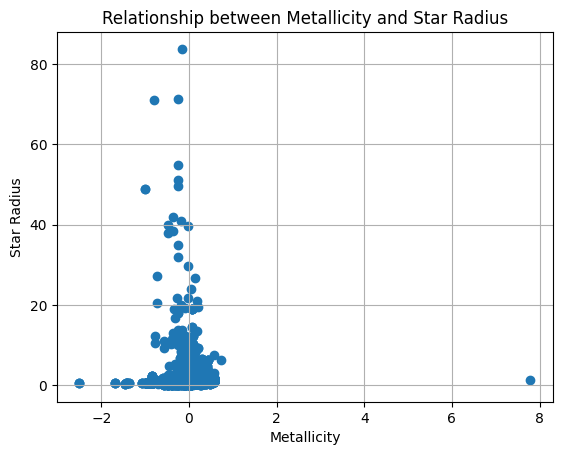

In [ ]:
plt.scatter(df_analyse['st_met'], df_analyse['st_rad'])
plt.xlabel('Metallicity')
plt.ylabel('Star Radius')
plt.title('Relationship between Metallicity and Star Radius')
plt.grid(True)
plt.show()

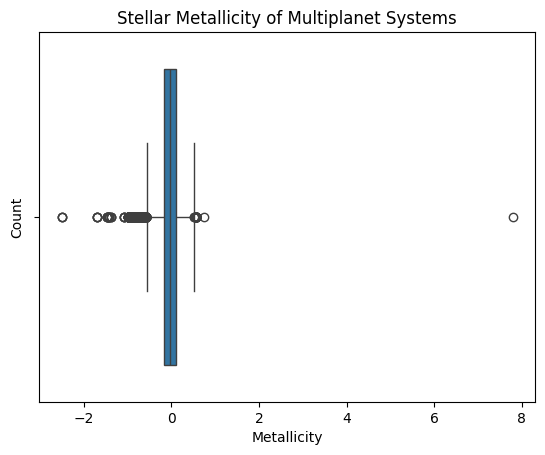

In [ ]:
sns.boxplot(data=multiplanet_df, x='st_met')
plt.title('Stellar Metallicity of Multiplanet Systems')
plt.xlabel('Metallicity')
plt.ylabel('Count')
plt.show()

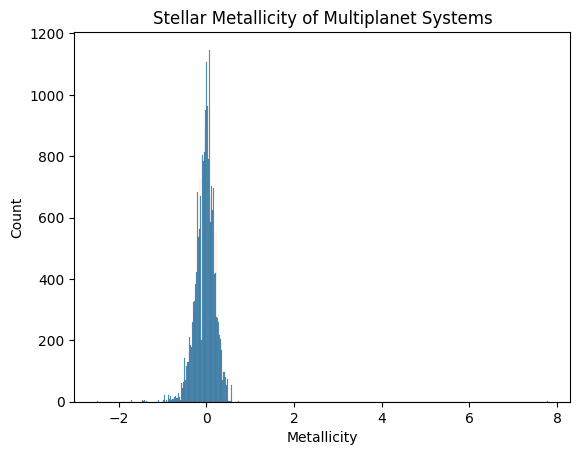

In [ ]:
sns.histplot(data=multiplanet_df, x='st_met')
plt.title('Stellar Metallicity of Multiplanet Systems')
plt.xlabel('Metallicity')
plt.ylabel('Count')
plt.show()

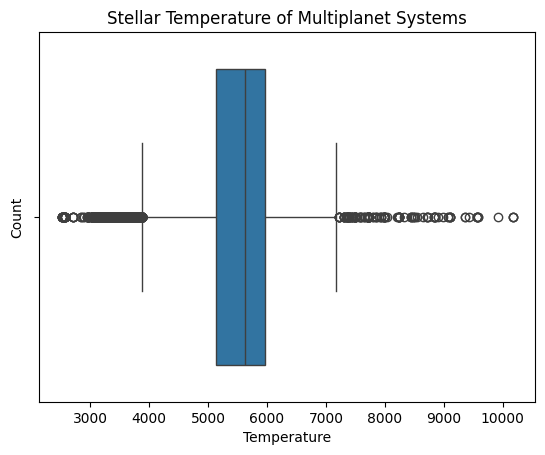

In [ ]:
sns.boxplot(data=multiplanet_df, x='st_teff')
plt.title('Stellar Temperature of Multiplanet Systems')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

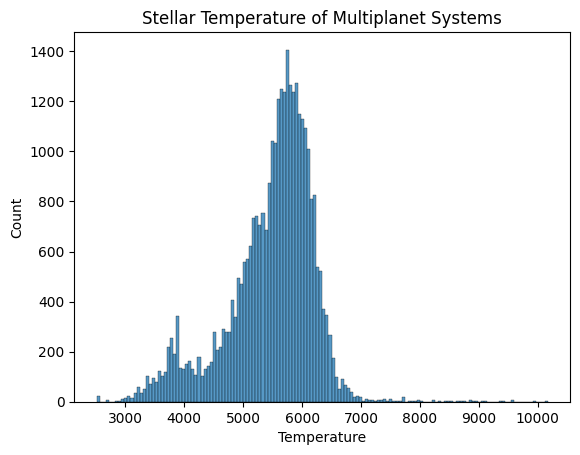

In [ ]:
sns.histplot(data=multiplanet_df, x='st_teff')
plt.title('Stellar Temperature of Multiplanet Systems')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

In [ ]:
df['st_teff'].describe()

,st_teff
count,35228.000000
mean,5465.719222
std,993.453869
min,415.000000
25%,5103.000000
50%,5614.000000
75%,5952.000000
max,57000.000000


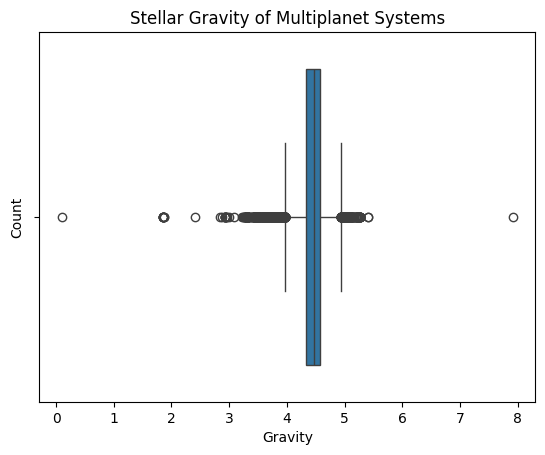

In [ ]:
sns.boxplot(data=multiplanet_df, x='st_logg')
plt.title('Stellar Gravity of Multiplanet Systems')
plt.xlabel('Gravity')
plt.ylabel('Count')
plt.show()

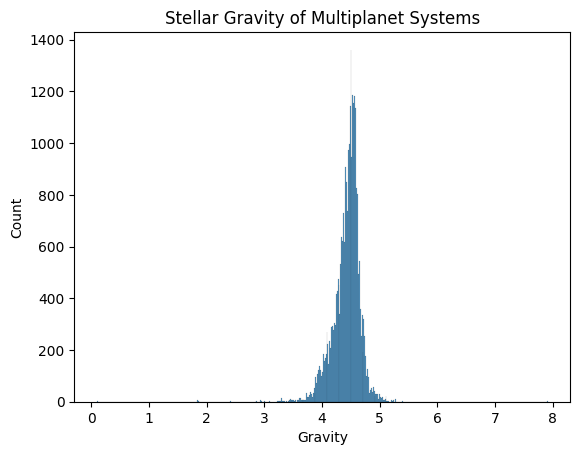

In [ ]:
sns.histplot(data=multiplanet_df, x='st_logg')
plt.title('Stellar Gravity of Multiplanet Systems')
plt.xlabel('Gravity')
plt.ylabel('Count')
plt.show()

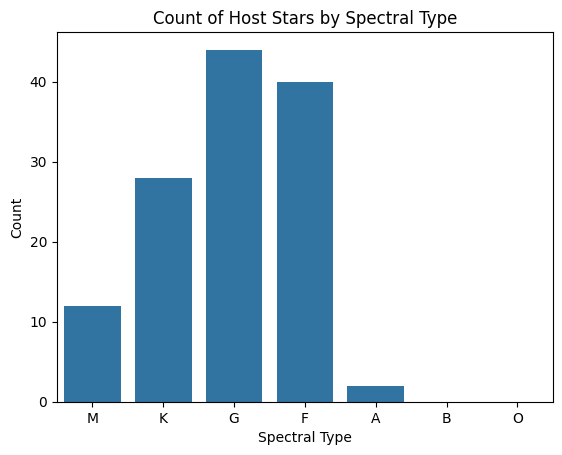

In [ ]:
sns.countplot(data=multiplanet_df, x='st_spectype', order=['M', 'K', 'G', 'F', 'A', 'B', 'O'])
plt.title('Count of Host Stars by Spectral Type')
plt.xlabel('Spectral Type')
plt.ylabel('Count')
plt.show()

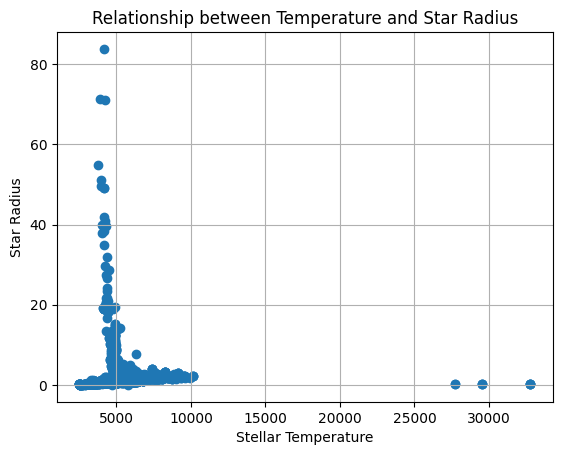

In [ ]:
plt.scatter(df_analyse['st_teff'], df_analyse['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.grid(True)
plt.show()

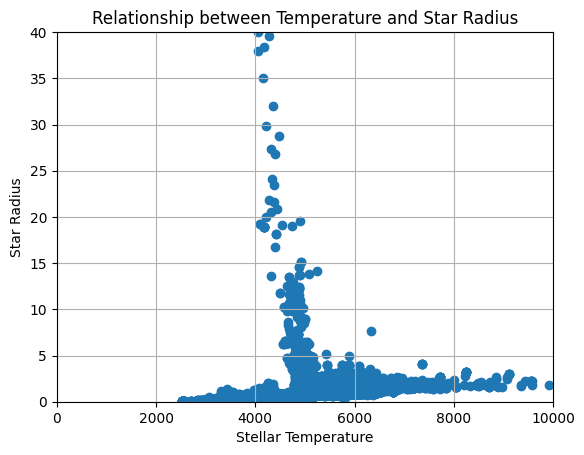

In [ ]:
plt.scatter(df_analyse['st_teff'], df_analyse['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.xlim(0, 10000)
plt.ylim(0, 40)
plt.grid(True)
plt.show()

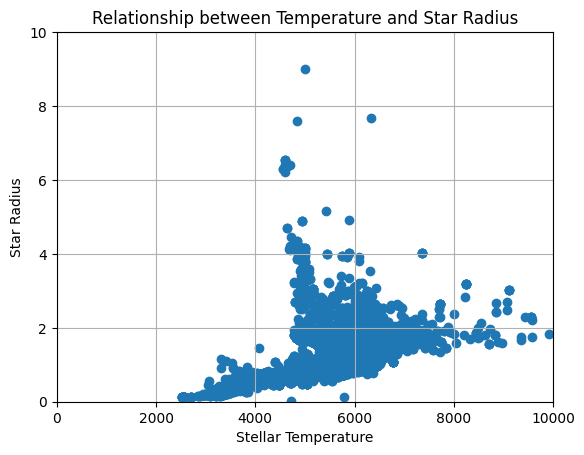

In [ ]:
plt.scatter(multiplanet_df['st_teff'], multiplanet_df['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.xlim(0, 10000)
plt.ylim(0, 10)
plt.grid(True)
plt.show()

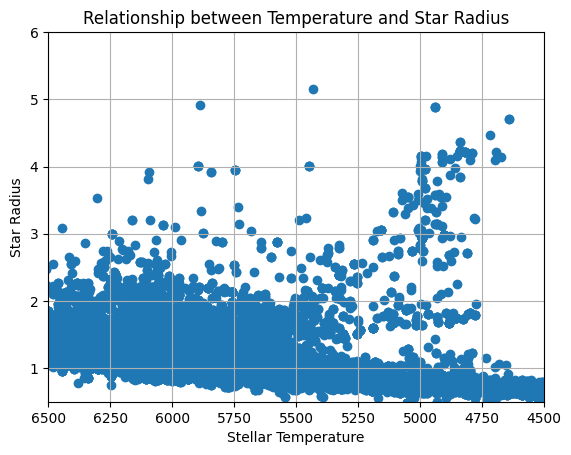

In [ ]:
plt.scatter(multiplanet_df['st_teff'], multiplanet_df['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.xlim(6500, 4500)
plt.ylim(0.5, 6)
plt.grid(True)
plt.show()

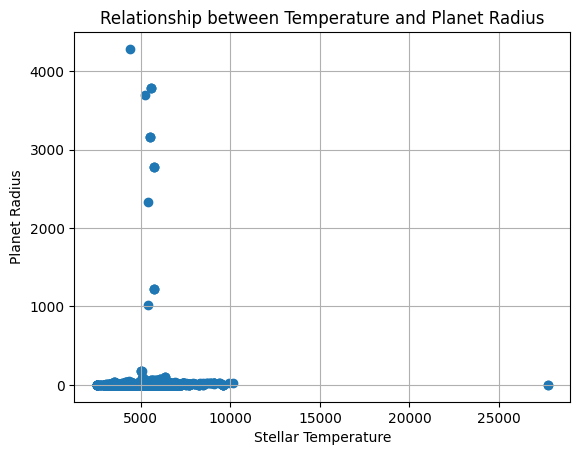

In [ ]:
plt.scatter(df_analyse['st_teff'], df_analyse['pl_rade'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Planet Radius')
plt.title('Relationship between Temperature and Planet Radius')
plt.grid(True)
plt.show()

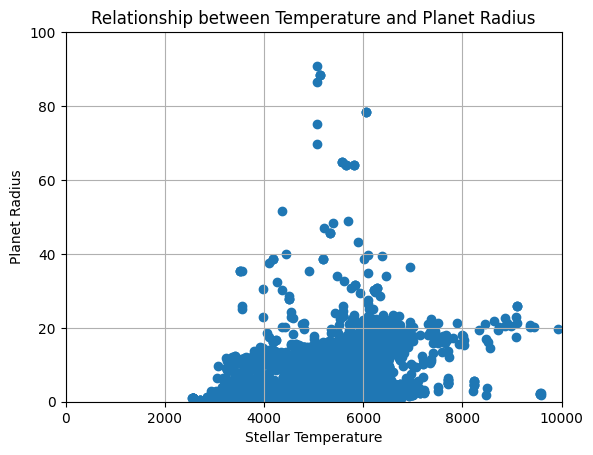

In [ ]:
plt.scatter(df_analyse['st_teff'], df_analyse['pl_rade'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Planet Radius')
plt.title('Relationship between Temperature and Planet Radius')
plt.grid(True)
plt.xlim(0, 10000)
plt.ylim(0, 100)
plt.show()

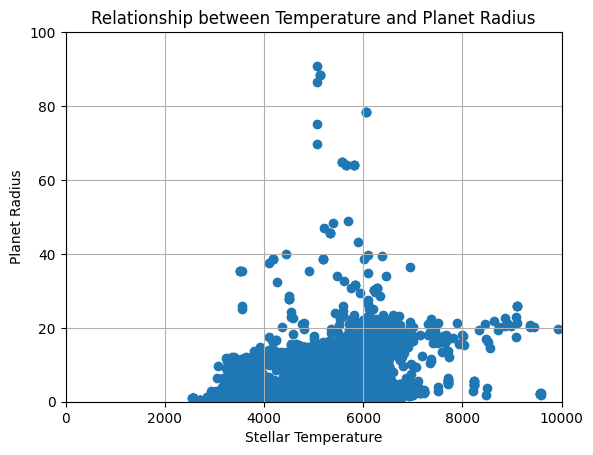

In [ ]:
plt.scatter(multiplanet_df['st_teff'], multiplanet_df['pl_rade'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Planet Radius')
plt.title('Relationship between Temperature and Planet Radius')
plt.grid(True)
plt.xlim(0, 10000)
plt.ylim(0, 100)
plt.show()

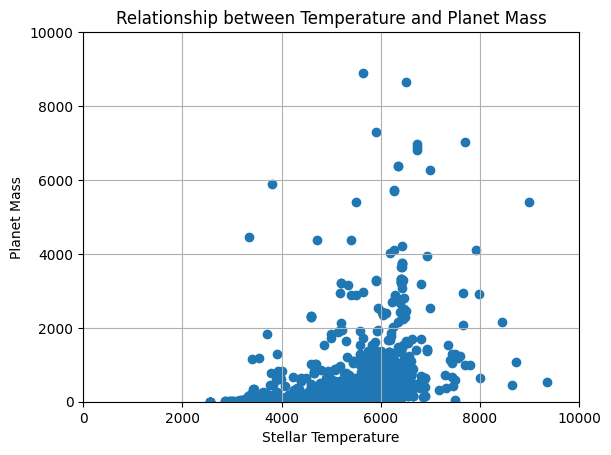

In [ ]:
plt.scatter(multiplanet_df['st_teff'], multiplanet_df['pl_bmasse'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Planet Mass')
plt.title('Relationship between Temperature and Planet Mass')
plt.grid(True)
plt.xlim(0, 10000)
plt.ylim(0, 10000)
plt.show()

In [ ]:
df['pl_rade'].isnull().sum()

np.int64(11919)

In [ ]:
df.dropna(subset=['pl_rade'], inplace=True)

In [ ]:
df['pl_rade'].isnull().sum()

np.int64(0)

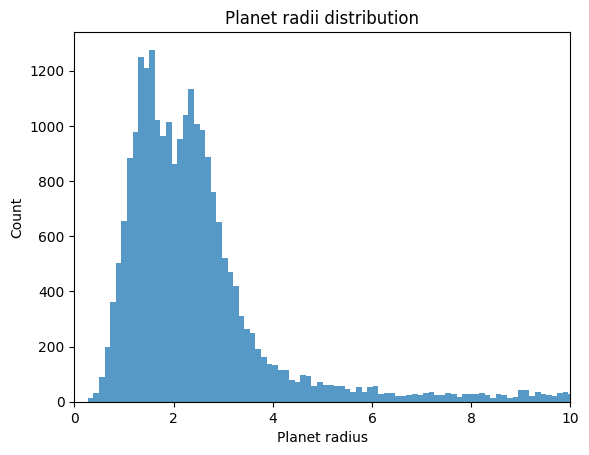

In [ ]:
sns.histplot(data=df, x='pl_rade')
plt.title('Planet radii distribution')
plt.xlabel('Planet radius')
plt.ylabel('Count')
plt.xlim(0, 10)
plt.show()

In [ ]:
transits_df = df[df['discoverymethod'] == 'Transit']

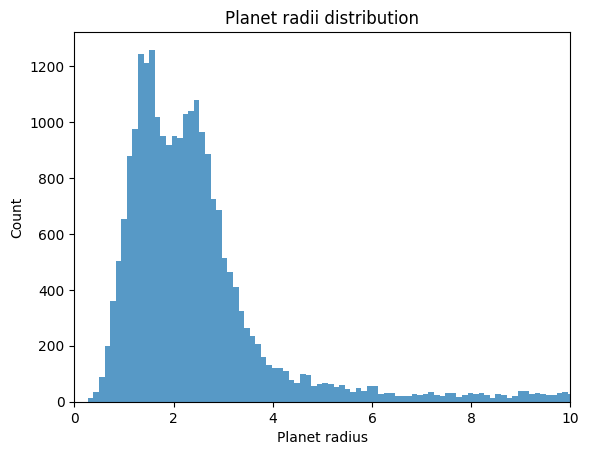

In [ ]:
sns.histplot(data=transits_df, x='pl_rade')
plt.title('Planet radii distribution')
plt.xlabel('Planet radius')
plt.ylabel('Count')
plt.xlim(0, 10)
plt.show()

In [ ]:
orbperiod_df = transits_df[transits_df['pl_orbper'] < 100]

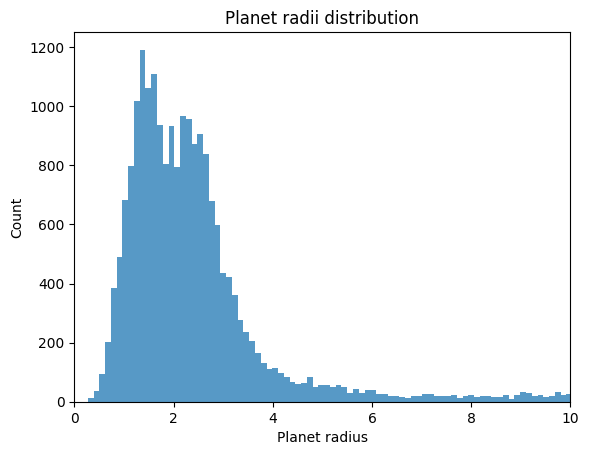

In [ ]:
sns.histplot(data=orbperiod_df, x='pl_rade')
plt.title('Planet radii distribution')
plt.xlabel('Planet radius')
plt.ylabel('Count')
plt.xlim(0, 10)
plt.show()

In [ ]:
temp_df = transits_df[(transits_df['st_teff'] > 4700) & (transits_df['st_teff'] < 6500)]

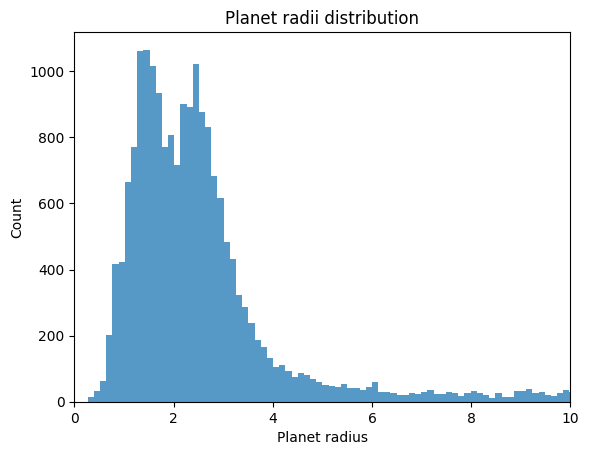

In [ ]:
sns.histplot(data=temp_df, x='pl_rade')
plt.title('Planet radii distribution')
plt.xlabel('Planet radius')
plt.ylabel('Count')
plt.xlim(0, 10)
plt.show()

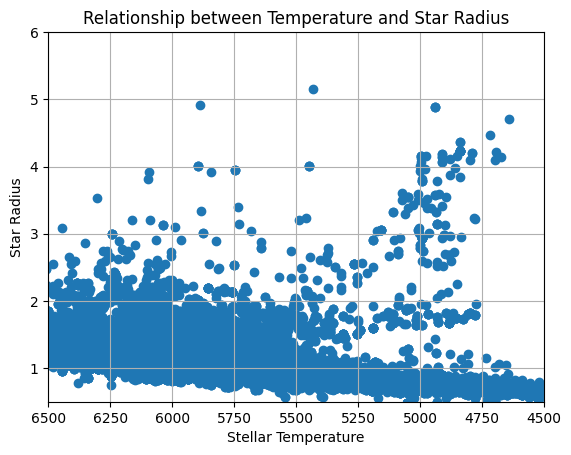

In [ ]:
plt.scatter(transits_df['st_teff'], transits_df['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.xlim(6500, 4500)
plt.ylim(0.5, 6)
plt.grid(True)
plt.show()

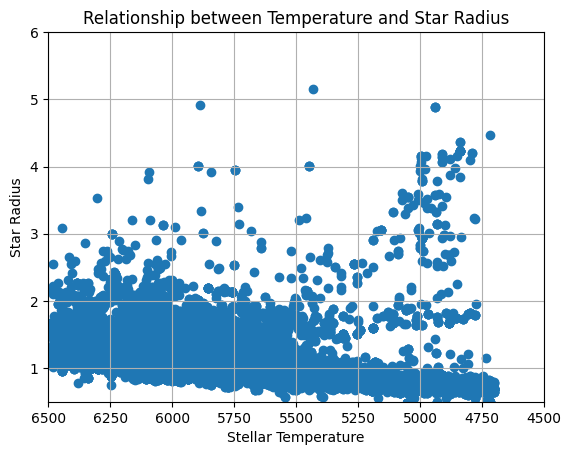

In [ ]:
plt.scatter(temp_df['st_teff'], temp_df['st_rad'])
plt.xlabel('Stellar Temperature')
plt.ylabel('Star Radius')
plt.title('Relationship between Temperature and Star Radius')
plt.xlim(6500, 4500)
plt.ylim(0.5, 6)
plt.grid(True)
plt.show()

In [ ]:
temp_df['hostname'].value_counts()

,count
hostname,
Kepler-11,60
Kepler-20,55
KOI-351,53
Kepler-102,51
Kepler-107,48
...,...
K2-202,1
K2-205,1
K2-173,1


In [ ]:
temp_df['value_counts'] = temp_df['hostname'].map(temp_df['hostname'].value_counts())
temp_df

/tmp/ipython-input-50-596227688.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_df['value_counts'] = temp_df['hostname'].map(temp_df['hostname'].value_counts())


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate,value_counts
195,BD+20 594 b,BD+20 594,1,1,1,Transit,2016,K2,Published Confirmed,0,...,9.368,0.018,-0.018,10.8644,0.000249,-0.000249,25-04-2018,2017-03,26-04-2018,3
196,BD+20 594 b,BD+20 594,0,1,1,Transit,2016,K2,Published Confirmed,0,...,9.368,0.018,-0.018,10.8644,0.000249,-0.000249,25-04-2018,2016-10,28-07-2016,3
197,BD+20 594 b,BD+20 594,0,1,1,Transit,2016,K2,Published Confirmed,0,...,9.368,0.018,-0.018,10.8644,0.000249,-0.000249,25-04-2018,2018-03,15-02-2018,3
242,CoRoT-1 b,CoRoT-1,1,1,1,Transit,2008,CoRoT,Published Confirmed,0,...,12.149,0.027,-0.027,13.4570,0.000477,-0.000477,14-05-2014,2008-05,14-05-2014,6
243,CoRoT-1 b,CoRoT-1,0,1,1,Transit,2008,CoRoT,Published Confirmed,0,...,12.149,0.027,-0.027,13.4570,0.000477,-0.000477,18-03-2019,2017-06,21-03-2019,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38291,XO-7 b,XO-7,1,1,1,Transit,2019,XO,Published Confirmed,0,...,9.241,0.024,-0.024,10.4575,0.000449,-0.000449,13-01-2020,2020-02,16-01-2020,3
38378,pi Men c,HD 39091,0,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),TESS Project Candidate,0,...,4.241,0.027,-0.027,5.5128,0.001946,-0.001946,10-04-2023,2017-07,10-04-2023,4
38380,pi Men c,HD 39091,1,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,4.241,0.027,-0.027,5.5128,0.001946,-0.001946,03-03-2025,2020-10,03-03-2025,4
38381,pi Men c,HD 39091,0,1,3,Transit,2018,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,4.241,0.027,-0.027,5.5128,0.001946,-0.001946,26-11-2018,2018-11,29-11-2018,4


In [ ]:
temp_df['st_rad'].describe()

,st_rad
count,21052.000000
mean,1.077885
std,0.406875
min,0.013100
25%,0.844000
50%,0.975006
75%,1.186000
max,19.530000


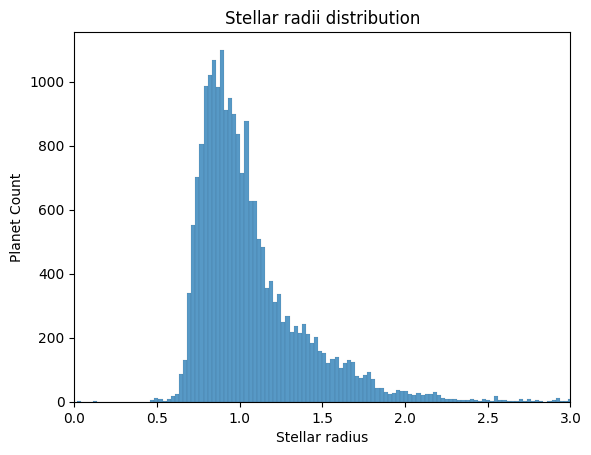

In [ ]:
sns.histplot(data=temp_df, x='st_rad')
plt.title('Stellar radii distribution')
plt.xlabel('Stellar radius')
plt.ylabel('Planet Count')
plt.xlim(0, 3)
plt.show()

Next section includes point by point plots

In [ ]:
radius_df = df[df['pl_rade'] != np.nan]

In [ ]:
radius_df['pl_rade']

,pl_rade
30,18.64700
39,11.20900
40,16.14096
106,1.91000
109,2.08000
...,...
38315,18.49485
38378,1.99779
38380,2.11000
38381,2.06000


In [ ]:
# Database should include multiple planets with radii measurements and following conditions
# 1) Host stars having temperatures 3000-7000 degree Kelvin
# 2) Radius of planets <= 4 R_earth
# star name (eg TOI700), host stellar mass, radius, temperature , metallicty and age (if available) for all stars, for the planet keep a record of planet name (eg TOI700-b), planet mass, radius, orbital separation (a), ecc (if available).

# cannot add all parameters at one so first filter then add columns

filtered_df = radius_df[
    (radius_df['pl_rade'] <= 4) &
    (radius_df['st_teff'] >= 3000) &
    (radius_df['st_teff'] <= 7000)
]

In [ ]:
filtered_df['pl_name'].nunique()

3412

In [ ]:
filtered_df['releasedate'] = pd.to_datetime(filtered_df['releasedate'], format='mixed', errors='coerce')

print("Unparsable release dates:", filtered_df['releasedate'].isna().sum())

Unparsable release dates: 0


/tmp/ipython-input-57-3208876763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['releasedate'] = pd.to_datetime(filtered_df['releasedate'], format='mixed', errors='coerce')


In [ ]:
filtered_df = filtered_df.dropna(subset=['releasedate'])

filtered_df_sorted = filtered_df.sort_values(by='releasedate', ascending=False)

filtered_df_latest = filtered_df_sorted.drop_duplicates(subset='pl_name', keep='first').reset_index(drop=True)

In [ ]:
multi_hosts = filtered_df_latest['hostname'].value_counts()
multi_hosts = multi_hosts[multi_hosts > 1].index

In [ ]:
multiplanets_df = filtered_df_latest[filtered_df_latest['hostname'].isin(multi_hosts)]
multiplanets_df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,HD 15337 c,HD 15337,1,1,2,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,7.044,0.018,-0.018,8.85598,0.000178,-0.000178,12-02-2025,2024-06,2025-12-02
1,HD 15337 b,HD 15337,1,1,2,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,7.044,0.018,-0.018,8.85598,0.000178,-0.000178,12-02-2025,2024-06,2025-12-02
7,GJ 9827 b,GJ 9827,1,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
8,GJ 9827 d,GJ 9827,0,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
9,GJ 9827 c,GJ 9827,1,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3400,Kepler-37 e,Kepler-37,0,1,4,Transit Timing Variations,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.004,7.942,0.013,-0.013,9.54988,0.000258,-0.000258,28-10-2013,08-01-2014,2013-10-28
3401,Kepler-108 b,Kepler-108,0,2,2,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.069,10.983,0.017,-0.017,13.08430,0.015753,-0.015753,28-10-2013,08-01-2014,2013-10-28
3402,Kepler-108 c,Kepler-108,0,2,2,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.069,10.983,0.017,-0.017,13.08430,0.015753,-0.015753,28-10-2013,08-01-2014,2013-10-28
3403,Kepler-247 c,Kepler-247,0,1,3,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.240,13.051,0.026,-0.026,15.04730,0.000466,-0.000466,28-10-2013,08-01-2014,2013-10-28


In [ ]:
multiplanets_df.reset_index(drop=True, inplace=True)
multiplanets_df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,HD 15337 c,HD 15337,1,1,2,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,7.044,0.018,-0.018,8.85598,0.000178,-0.000178,12-02-2025,2024-06,2025-12-02
1,HD 15337 b,HD 15337,1,1,2,Transit,2019,Transiting Exoplanet Survey Satellite (TESS),Published Confirmed,0,...,-0.030,7.044,0.018,-0.018,8.85598,0.000178,-0.000178,12-02-2025,2024-06,2025-12-02
2,GJ 9827 b,GJ 9827,1,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
3,GJ 9827 d,GJ 9827,0,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
4,GJ 9827 c,GJ 9827,1,1,3,Transit,2017,K2,Published Confirmed,0,...,-0.030,7.193,0.024,-0.024,9.83773,0.000411,-0.000411,09-01-2025,2024-01,2025-09-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,Kepler-37 e,Kepler-37,0,1,4,Transit Timing Variations,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.004,7.942,0.013,-0.013,9.54988,0.000258,-0.000258,28-10-2013,08-01-2014,2013-10-28
1580,Kepler-108 b,Kepler-108,0,2,2,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.069,10.983,0.017,-0.017,13.08430,0.015753,-0.015753,28-10-2013,08-01-2014,2013-10-28
1581,Kepler-108 c,Kepler-108,0,2,2,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.069,10.983,0.017,-0.017,13.08430,0.015753,-0.015753,28-10-2013,08-01-2014,2013-10-28
1582,Kepler-247 c,Kepler-247,0,1,3,Transit,2014,Kepler,Kepler Project Candidate (q1_q8_koi),0,...,-0.240,13.051,0.026,-0.026,15.04730,0.000466,-0.000466,28-10-2013,08-01-2014,2013-10-28


In [ ]:
multi_planet_df = multiplanets_df[
    ['hostname', 'st_mass', 'st_rad', 'st_teff', 'st_met', 'pl_name', 'pl_bmasse', 'pl_rade', 'pl_orbsmax', 'pl_orbeccen', 'pl_insol']   # explicit stellar age not available but can be estimated
]
multi_planet_df

,hostname,st_mass,st_rad,st_teff,st_met,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol
0,HD 15337,0.829,0.855,5131.0,0.03,HD 15337 c,6.792,2.526,NaN,0.096,NaN
1,HD 15337,0.829,0.855,5131.0,0.03,HD 15337 b,6.519,1.770,NaN,0.058,NaN
2,GJ 9827,0.620,0.580,4236.0,-0.29,GJ 9827 b,4.280,1.440,0.0189,NaN,NaN
3,GJ 9827,0.620,0.580,4236.0,-0.29,GJ 9827 d,3.020,1.890,0.0563,NaN,NaN
4,GJ 9827,0.620,0.580,4236.0,-0.29,GJ 9827 c,1.860,1.130,0.0395,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1579,Kepler-37,0.753,0.728,5288.0,NaN,Kepler-37 e,NaN,0.370,0.2460,0.000,NaN
1580,Kepler-108,0.890,0.940,5632.0,NaN,Kepler-108 b,NaN,3.900,0.2520,0.000,NaN
1581,Kepler-108,0.890,0.940,5632.0,NaN,Kepler-108 c,NaN,3.400,0.6220,0.000,NaN
1582,Kepler-247,0.773,0.680,5010.0,NaN,Kepler-247 c,NaN,3.800,0.0800,0.000,NaN


In [ ]:
multi_planet_df['hostname'].nunique()

630

In [ ]:
stellar_cols = ['st_mass', 'st_rad', 'st_teff', 'st_met']

# Function to get the mode safely
def get_mode(series):
    mode_vals = series.mode()
    return mode_vals.iloc[0] if not mode_vals.empty else pd.NA

# Apply mode to each column per host star
stellar_mode_df = multi_planet_df.groupby('hostname')[stellar_cols].agg(get_mode).reset_index()

# Drop the original (inconsistent) stellar columns
multi_planet_df = multi_planet_df.drop(columns=stellar_cols)

# Merge the cleaned mode values back into the original DataFrame
multi_planet_df = multi_planet_df.merge(stellar_mode_df, on='hostname', how='left')

In [ ]:
multi_planet_df['pl_insol'].isnull().sum()

np.int64(307)

In [ ]:
multi_planet_df = multi_planet_df.sort_values(by=['hostname', 'pl_name']).reset_index(drop=True)

In [ ]:
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met
0,AU Mic,AU Mic b,NaN,3.956770,0.0649,0.00577,21.2000,0.51,0.744000,3678.0,0.23
1,AU Mic,AU Mic c,NaN,2.522021,0.1108,0.00338,7.3000,0.51,0.744000,3678.0,0.23
2,EPIC 206024342,EPIC 206024342 c,NaN,1.400000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22
3,EPIC 206024342,EPIC 206024342 d,NaN,2.600000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22
4,EPIC 206042996,EPIC 206042996 b,NaN,1.700000,NaN,NaN,NaN,<NA>,0.500000,4114.0,0.006
...,...,...,...,...,...,...,...,...,...,...,...
1579,TOI-836,TOI-836 c,NaN,2.640320,NaN,NaN,40.8229,<NA>,0.690000,4476.0,<NA>
1580,TOI-904,TOI-904 b,NaN,2.309613,NaN,NaN,8.3169,<NA>,0.532439,3992.0,<NA>
1581,TOI-904,TOI-904 c,NaN,2.340834,NaN,NaN,0.5449,<NA>,0.532439,3992.0,<NA>
1582,WASP-47,WASP-47 d,14.20,3.567000,NaN,0.01000,NaN,1.04,1.137000,5552.0,0.38


In [ ]:
#!pip install --upgrade gspread gspread_dataframe google-auth google-auth-oauthlib

In [ ]:
#import gspread
#import pandas as pd
#from gspread_dataframe import set_with_dataframe
#from google.colab import auth
#import google.auth

# Authenticate
#auth.authenticate_user()
#creds, _ = google.auth.default()

# Authorize gspread
#gc = gspread.authorize(creds)

In [ ]:
# Create new sheet
#sh = gc.create('Cleaned Dataset')

# Select first worksheet
#worksheet = sh.sheet1

# Upload DataFrame
#set_with_dataframe(worksheet, multi_planet_df)

In [ ]:
#sh.share('yashasvee.v.taiwade@gmail.com', perm_type='user', role='writer')

In [ ]:
multi_planet_df['pl_insol'].isnull().sum()

np.int64(307)

It can be seen that most of the insolation flux values are missing. There are two which I will be doing here I will be finding stellar irradiation for each planet and for the planets which have the insolation flux value available, the value will be first cross checked then stored.

In [ ]:
multi_planet_df['st_rad'].isnull().sum()

np.int64(0)

In [ ]:
multi_planet_df['st_teff'].isnull().sum()

np.int64(0)

In [ ]:
multi_planet_df.shape

(1584, 11)

Stellar irradiation also known as the stellar flux is the amount of energy per area emitted by a star to a planet because of the star's radiation. \
$ S = \frac{L^*}{4 \pi a^2}  $ \
where L is the star luminosity in watt and a is orbital separation in m. \
Insolation flux however is the amount received by a particular planet.

Star luminosity : $ L = 4 \pi R_*^2 σ T_*^4$

For this section the case might be that

In [ ]:
sig = 5.670367e-8
multi_planet_df['st_lum'] = 4 * np.pi * np.power((multi_planet_df['st_rad'] * 6.957e8),2) * sig * np.power((multi_planet_df['st_teff']),4)
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum
0,AU Mic,AU Mic b,NaN,3.956770,0.0649,0.00577,21.2000,0.51,0.744000,3678.0,0.23,3.493476e+25
1,AU Mic,AU Mic c,NaN,2.522021,0.1108,0.00338,7.3000,0.51,0.744000,3678.0,0.23,3.493476e+25
2,EPIC 206024342,EPIC 206024342 c,NaN,1.400000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26
3,EPIC 206024342,EPIC 206024342 d,NaN,2.600000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26
4,EPIC 206042996,EPIC 206042996 b,NaN,1.700000,NaN,NaN,NaN,<NA>,0.500000,4114.0,0.006,2.469802e+25
...,...,...,...,...,...,...,...,...,...,...,...,...
1579,TOI-836,TOI-836 c,NaN,2.640320,NaN,NaN,40.8229,<NA>,0.690000,4476.0,<NA>,6.590578e+25
1580,TOI-904,TOI-904 b,NaN,2.309613,NaN,NaN,8.3169,<NA>,0.532439,3992.0,<NA>,2.482944e+25
1581,TOI-904,TOI-904 c,NaN,2.340834,NaN,NaN,0.5449,<NA>,0.532439,3992.0,<NA>,2.482944e+25
1582,WASP-47,WASP-47 d,14.20,3.567000,NaN,0.01000,NaN,1.04,1.137000,5552.0,0.38,4.236272e+26


In [ ]:
# (A) Calculate the stellar irradiation each planet receives. Denote this by S. Tell me how will you do this?? Note these values

multi_planet_df['S'] = multi_planet_df['st_lum'] / (4 * np.pi * np.power((multi_planet_df['pl_orbsmax']*1.496e11), 2))
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S
0,AU Mic,AU Mic b,NaN,3.956770,0.0649,0.00577,21.2000,0.51,0.744000,3678.0,0.23,3.493476e+25,29491.398338
1,AU Mic,AU Mic c,NaN,2.522021,0.1108,0.00338,7.3000,0.51,0.744000,3678.0,0.23,3.493476e+25,10118.246093
2,EPIC 206024342,EPIC 206024342 c,NaN,1.400000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26,NaN
3,EPIC 206024342,EPIC 206024342 d,NaN,2.600000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26,NaN
4,EPIC 206042996,EPIC 206042996 b,NaN,1.700000,NaN,NaN,NaN,<NA>,0.500000,4114.0,0.006,2.469802e+25,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,TOI-836,TOI-836 c,NaN,2.640320,NaN,NaN,40.8229,<NA>,0.690000,4476.0,<NA>,6.590578e+25,NaN
1580,TOI-904,TOI-904 b,NaN,2.309613,NaN,NaN,8.3169,<NA>,0.532439,3992.0,<NA>,2.482944e+25,NaN
1581,TOI-904,TOI-904 c,NaN,2.340834,NaN,NaN,0.5449,<NA>,0.532439,3992.0,<NA>,2.482944e+25,NaN
1582,WASP-47,WASP-47 d,14.20,3.567000,NaN,0.01000,NaN,1.04,1.137000,5552.0,0.38,4.236272e+26,NaN


In [ ]:
multi_planet_df['pl_stir'] = multi_planet_df['S'] / 1361
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir
0,AU Mic,AU Mic b,NaN,3.956770,0.0649,0.00577,21.2000,0.51,0.744000,3678.0,0.23,3.493476e+25,29491.398338,21.668919
1,AU Mic,AU Mic c,NaN,2.522021,0.1108,0.00338,7.3000,0.51,0.744000,3678.0,0.23,3.493476e+25,10118.246093,7.434420
2,EPIC 206024342,EPIC 206024342 c,NaN,1.400000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26,NaN,NaN
3,EPIC 206024342,EPIC 206024342 d,NaN,2.600000,NaN,NaN,NaN,<NA>,1.100000,5724.0,-0.22,4.479700e+26,NaN,NaN
4,EPIC 206042996,EPIC 206042996 b,NaN,1.700000,NaN,NaN,NaN,<NA>,0.500000,4114.0,0.006,2.469802e+25,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,TOI-836,TOI-836 c,NaN,2.640320,NaN,NaN,40.8229,<NA>,0.690000,4476.0,<NA>,6.590578e+25,NaN,NaN
1580,TOI-904,TOI-904 b,NaN,2.309613,NaN,NaN,8.3169,<NA>,0.532439,3992.0,<NA>,2.482944e+25,NaN,NaN
1581,TOI-904,TOI-904 c,NaN,2.340834,NaN,NaN,0.5449,<NA>,0.532439,3992.0,<NA>,2.482944e+25,NaN,NaN
1582,WASP-47,WASP-47 d,14.20,3.567000,NaN,0.01000,NaN,1.04,1.137000,5552.0,0.38,4.236272e+26,NaN,NaN


From the above we can see that the insolation flux and stellar irradiation received by each planet which was calculated are similar with slight differences which can be a result of approximations of values made.

For the next one there is a simple code below but gives difference between consecutive planet radii. One another method which was thought of was of subtracting each planet radii by minimum radii available which is not necessary to correspond to the innermost planet. \\
Then again the nomenclature in itself does not correspond to the order of planet's positioning (innermost to outermost or vice-versa) it is based on order of the discovery. \\
So to find the innermost and outermost planet we can sort using the orbital separation and then subtract the value of the least orbital separation from the rest which will lead to delR.

In [ ]:
multi_planet_df['pl_insol'].isnull().sum()

np.int64(307)

In [ ]:
multi_planet_df['pl_stir'].isnull().sum()

np.int64(550)

In [ ]:
#import gspread
#import pandas as pd
#from gspread_dataframe import set_with_dataframe
#from google.colab import auth
#import google.auth

# Authenticate
#auth.authenticate_user()
#creds, _ = google.auth.default()

# Authorize gspread
#gc = gspread.authorize(creds)

In [ ]:
#sh = gc.create('Stellar_ir Dataset')

# Select first worksheet
#worksheet = sh.sheet1

# Upload DataFrame
#set_with_dataframe(worksheet, multi_planet_df)

In [ ]:
#sh.share('yashasvee.v.taiwade@gmail.com', perm_type='user', role='writer')

In [ ]:
# Drop rows with nulls in 'pl_insol'
df_insol_clean = multi_planet_df[multi_planet_df['pl_insol'].notna()]

# Drop rows with nulls in 'pl_stir'
df_stir_clean = multi_planet_df[multi_planet_df['pl_stir'].notna()]

In [ ]:
df_insol_clean

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.2000,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.3000,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420
14,EPIC 220674823,EPIC 220674823 b,7.80,1.676000,0.01314,0.00000,4656.0000,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858
15,EPIC 220674823,EPIC 220674823 c,7.32,2.840000,0.10730,0.17000,70.0000,0.913,0.990000,5578.0,-0.005,3.272273e+26,1.010595e+05,74.253828
16,EPIC 249893012,EPIC 249893012 b,8.75,1.950000,0.04700,0.06000,1037.0000,1.05,1.710000,5430.0,0.2,8.767112e+26,1.411198e+06,1036.882838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1577,TOI-815,TOI-815 c,NaN,2.183800,NaN,NaN,9.0444,<NA>,0.760000,4953.9,<NA>,1.199724e+26,NaN,NaN
1578,TOI-836,TOI-836 b,NaN,1.692570,NaN,NaN,40.9119,<NA>,0.690000,4476.0,<NA>,6.590578e+25,NaN,NaN
1579,TOI-836,TOI-836 c,NaN,2.640320,NaN,NaN,40.8229,<NA>,0.690000,4476.0,<NA>,6.590578e+25,NaN,NaN
1580,TOI-904,TOI-904 b,NaN,2.309613,NaN,NaN,8.3169,<NA>,0.532439,3992.0,<NA>,2.482944e+25,NaN,NaN


In [ ]:
df_stir_clean

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420
12,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053
13,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622
14,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341
1552,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065
1556,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953
1557,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945


In [ ]:
multi_planet_df['combined_insol_stir'] = multi_planet_df['pl_insol'].combine_first(multi_planet_df['pl_stir'])

In [ ]:
 df_combined = multi_planet_df[multi_planet_df['combined_insol_stir'].notna()]

In [ ]:
# Save all 3 + original to Excel
"""with pd.ExcelWriter("combined_cleaned_data.xlsx") as writer:
    multi_planet_df.to_excel(writer, sheet_name="Original_Data", index=False)
    df_insol_clean.to_excel(writer, sheet_name="No_Null_pl_insol", index=False)
    df_stir_clean.to_excel(writer, sheet_name="No_Null_pl_stir", index=False)
    df_combined.to_excel(writer, sheet_name="Combined_Cleaned", index=False)"""

'with pd.ExcelWriter("combined_cleaned_data.xlsx") as writer:\n    multi_planet_df.to_excel(writer, sheet_name="Original_Data", index=False)\n    df_insol_clean.to_excel(writer, sheet_name="No_Null_pl_insol", index=False)\n    df_stir_clean.to_excel(writer, sheet_name="No_Null_pl_stir", index=False)\n    df_combined.to_excel(writer, sheet_name="Combined_Cleaned", index=False)'

In [ ]:
df_diff = df.copy()

In [ ]:
multi_planet_df = multi_planet_df[multi_planet_df['pl_orbsmax'].notna()]

In [ ]:
innermost_radii = multi_planet_df.groupby('hostname')['pl_rade'].transform('first')
multi_planet_df['delR'] = innermost_radii - multi_planet_df['pl_rade']
multi_planet_df

/tmp/ipython-input-92-2206042670.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi_planet_df['delR'] = innermost_radii - multi_planet_df['pl_rade']


,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,1.434750
12,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000
13,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104000
14,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000
1552,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149000
1556,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000
1557,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,-1.470455


In [ ]:
multi_planet_df = multi_planet_df.sort_values(by=['hostname', 'pl_name']).reset_index(drop=True)

In [ ]:
multi_df = multi_planet_df.sort_values(by=['hostname', 'pl_orbsmax'])
multi_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,1.434750
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104000
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000
1030,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149000
1031,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000
1032,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,-1.470455


In [ ]:
# (B) Calculate deltaR as the difference of radius of outer planet from the inner most. For example if a star TOI 700 has planets b, c, d of radii 2.0, 3.0 and 4.0 R_earth radius, compute delR_(b-c), delR_(b-d) for the three planets. These will be 1 and 2 R_earth respectively in this specific case, so for 3 planets, you have two delR values.

innermost_radii = multi_df.groupby('hostname')['pl_rade'].transform('first')
multi_df['delR'] = multi_df['pl_rade'] - innermost_radii
multi_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,-1.434750
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,0.104000
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000
1030,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,0.149000
1031,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000
1032,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,1.470455


From below it can be noted that around 550 semi major axis values are missing while the radius values are still intact. \\
For their difference I will use the b, c, d and so on nomenclature based difference method for delR.

In [ ]:
multi_planet_df['pl_rade'].isnull().sum()

np.int64(0)

In [ ]:
multi_planet_df['pl_orbsmax'].isnull().sum()

np.int64(0)

In [ ]:
df['pl_orbsmax'].isnull().sum()

np.int64(8039)

In [ ]:
# (C) Similarly calculate del_log(S) for all planets in the system similarly

innermost_s = multi_planet_df.groupby('hostname')['pl_stir'].transform('first')
multi_planet_df['del_logS'] = np.log10(multi_planet_df['pl_stir']) - np.log10(innermost_s)

In [ ]:
# (C) Similarly calculate del_log(S) for all planets in the system similarly

innermost_s = multi_df.groupby('hostname')['pl_stir'].transform('first')
multi_df['del_logS'] = np.log10(multi_df['pl_stir']) - np.log10(innermost_s)

In [ ]:
print(multi_planet_df['del_logS'].dtype)

float64


In [ ]:
# (D) Now compute delR/del_log(S) for each planet pair in the system and plot this quantity as a function of host stellar temperature.

valid = (multi_planet_df['delR'] != 0) & (multi_planet_df['del_logS'] != 0)
multi_planet_df.loc[valid, 'delR/del_logS'] = multi_planet_df.loc[valid, 'delR'] / multi_planet_df.loc[valid, 'del_logS']
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000,0.000000,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,1.434750,-0.464590,-3.088205
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000,0.000000,NaN
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104000,-0.911864,0.114052
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000,0.000000,NaN
1030,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149000,-0.380765,0.391318
1031,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,0.000000,NaN
1032,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,-1.470455,-1.844972,0.797007


In [ ]:
valid = (multi_df['delR'] != 0) & (multi_df['del_logS'] != 0)
multi_df.loc[valid, 'delR/del_logS'] = multi_df.loc[valid, 'delR'] / multi_df.loc[valid, 'del_logS']
multi_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000,0.000000,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,-1.434750,-0.464590,3.088205
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000,0.000000,NaN
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,0.104000,-0.911864,-0.114052
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000,0.000000,NaN
1030,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,0.149000,-0.380765,-0.391318
1031,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,0.000000,NaN
1032,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,1.470455,-1.844972,-0.797007


In [ ]:
multi_planet_df[['del_logS', 'delR']] = multi_planet_df[['del_logS', 'delR']].replace(0,'')
multi_df[['del_logS', 'delR']] = multi_df[['del_logS', 'delR']].replace(0,'')

In [ ]:
multi_planet_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.0,0.23,3.493476e+25,2.949140e+04,21.668919,21.200000,,,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.0,0.23,3.493476e+25,1.011825e+04,7.434420,7.300000,1.43475,-0.46459,-3.088205
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,,,NaN
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.69,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104,-0.911864,0.114052
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,,,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1029,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,<NA>,2.865646e+25,3.695434e+04,27.152341,26.900000,,,NaN
1030,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,<NA>,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149,-0.380765,0.391318
1031,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,,,NaN
1032,TOI-561,TOI-561 c,6.9,2.927067,0.08700,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,9.322298e+04,68.495945,68.495945,-1.470455,-1.844972,0.797007


In [ ]:
M_df = multi_df[multi_df['st_teff']<4000]
M_df.reset_index(drop=True, inplace=True)
M_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.51,0.744000,3678.00,0.23,3.493476e+25,29491.398338,21.668919,21.200000,,,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.51,0.744000,3678.00,0.23,3.493476e+25,10118.246093,7.434420,7.300000,-1.43475,-0.46459,3.088205
2,K2-117,K2-117 c,NaN,2.060000,0.04920,NaN,NaN,0.54,0.510000,3689.00,-0.05,1.661269e+25,24402.636774,17.929932,17.929932,,,NaN
3,K2-133,K2-133 b,NaN,1.340000,0.03194,NaN,NaN,0.461,0.455000,3655.00,<NA>,1.274199e+25,44411.401953,32.631449,32.631449,,,NaN
4,K2-133,K2-133 c,NaN,1.603000,0.04341,NaN,NaN,0.461,0.455000,3655.00,<NA>,1.274199e+25,24042.782899,17.665527,17.665527,0.263,-0.26651,-0.986831
5,K2-133,K2-133 e,NaN,1.730000,0.13460,NaN,1.80,0.461,0.455000,3655.00,<NA>,1.274199e+25,2500.772511,1.837452,1.800000,0.39,-1.24942,-0.312145
6,K2-146,K2-146 b,5.60,2.250000,0.02480,0.14000,NaN,0.358,0.350000,3385.00,-0.02,5.546715e+24,32067.079405,23.561410,23.561410,,,NaN
7,K2-146,K2-146 c,7.10,2.590000,0.03270,0.16000,NaN,0.358,0.350000,3385.00,-0.02,5.546715e+24,18444.516003,13.552179,13.552179,0.34,-0.240192,-1.415533
8,K2-239,K2-239 b,NaN,1.100000,0.04410,NaN,NaN,0.4,0.360000,3420.00,-0.1,6.114690e+24,11179.547741,8.214216,8.214216,,,NaN
9,K2-239,K2-239 c,NaN,1.000000,0.05760,NaN,NaN,0.4,0.360000,3420.00,-0.1,6.114690e+24,6553.245636,4.815023,4.815023,-0.1,-0.231968,0.431094


In [ ]:
K_df = multi_df[(multi_df['st_teff']>=4000) & (multi_df['st_teff']<=5200)]
K_df.reset_index(drop=True, inplace=True)
K_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20,NaN,0.69,0.673,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,,,NaN
1,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20,NaN,0.69,0.673,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,0.104,-0.911864,-0.114052
2,GJ 9827,GJ 9827 b,4.28,1.440000,0.01890,NaN,NaN,0.62,0.580,4236.0,-0.29,3.735466e+25,3.718332e+05,273.205883,273.205883,,,NaN
3,GJ 9827,GJ 9827 c,1.86,1.130000,0.03950,NaN,NaN,0.62,0.580,4236.0,-0.29,3.735466e+25,8.512901e+04,62.548869,62.548869,-0.31,-0.640271,0.484170
4,GJ 9827,GJ 9827 d,3.02,1.890000,0.05630,NaN,NaN,0.62,0.580,4236.0,-0.29,3.735466e+25,4.190395e+04,30.789091,30.789091,0.45,-0.948093,-0.474637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,TOI-178,TOI-178 f,7.72,2.287000,0.10390,NaN,NaN,0.65,0.651,4111.0,-0.23,4.174620e+25,1.375032e+04,10.103100,10.103100,1.135,-1.200949,-0.945086
239,TOI-1798,TOI-1798.02,NaN,1.408220,0.01074,NaN,3575.67,0.862514,0.780,5165.2,<NA>,1.493492e+26,4.604133e+06,3382.904703,3575.670000,,,NaN
240,TOI-2076,TOI-2076 c,55.00,3.694416,0.14200,0.00,NaN,0.8557,0.796,5192.0,0.02,1.587925e+26,2.800143e+04,20.574157,20.574157,,,NaN
241,TOI-2076,TOI-2076 d,29.00,3.430878,0.19900,0.00,NaN,0.8557,0.796,5192.0,0.02,1.587925e+26,1.425774e+04,10.475930,10.475930,-0.263538,-0.293129,0.899051


In [ ]:
G_F_df = multi_df[multi_df['st_teff']>5200]
G_F_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
4,EPIC 220674823,EPIC 220674823 b,7.80,1.676000,0.01314,0.00,4656.0,0.913,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,,,NaN
5,EPIC 220674823,EPIC 220674823 c,7.32,2.840000,0.10730,0.17,70.0,0.913,0.990000,5578.0,-0.005,3.272273e+26,1.010595e+05,74.253828,70.000000,1.164,-1.824009,-0.638155
6,EPIC 249893012,EPIC 249893012 b,8.75,1.950000,0.04700,0.06,1037.0,1.05,1.710000,5430.0,0.2,8.767112e+26,1.411198e+06,1036.882838,1037.000000,,,NaN
7,EPIC 249893012,EPIC 249893012 c,14.67,3.670000,0.13000,0.07,160.0,1.05,1.710000,5430.0,0.2,8.767112e+26,1.844577e+05,135.531017,160.000000,1.72,-0.883691,-1.946382
8,EPIC 249893012,EPIC 249893012 d,10.18,3.940000,0.22000,0.15,53.0,1.05,1.710000,5430.0,0.2,8.767112e+26,6.440776e+04,47.323847,53.000000,1.99,-1.34065,-1.484355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,TOI-1246,TOI-1246 c,9.10,2.451098,0.06100,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.820602e+05,133.769433,133.769433,,,NaN
1015,TOI-1246,TOI-1246 d,5.40,3.431397,0.13200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,3.888005e+04,28.567267,28.567267,0.980299,-0.670488,-1.462067
1016,TOI-1246,TOI-1246 e,14.50,3.514187,0.21200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.507311e+04,11.075028,11.075028,1.063089,-1.082012,-0.982511
1031,TOI-561,TOI-561 b,3.00,1.456612,0.01040,0.00,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,,,NaN


In [ ]:
with pd.ExcelWriter("Final.xlsx") as writer:
   # multi_planet_df.to_excel(writer, sheet_name="Final_del", index=False)
    multi_df.to_excel(writer, sheet_name="Final_del_orb", index=False)
    M_df.to_excel(writer, sheet_name="M_type", index=False)
    K_df.to_excel(writer, sheet_name="K_type", index=False)
    G_F_df.to_excel(writer, sheet_name="G&F_type", index=False)

In [ ]:
valid_rows = multi_planet_df[
    (multi_planet_df['delR'] != 0) &
    (multi_planet_df['del_logS'] != 0) &
    (~multi_planet_df['delR/del_logS'].isna()) &
    (~np.isinf(multi_planet_df['delR/del_logS']))
]

In [ ]:
multi_planet_df['delR/del_logS'].describe()

In [ ]:
sns.scatterplot(data=valid_rows, x='st_teff', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.ylim(0, 100)
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
multi_df = pd.read_excel('Final (1).xlsx', sheet_name='Final_del_orb')
multi_df = multi_df.sort_values(by=['hostname', 'pl_orbsmax'])
innermost_radii = multi_df.groupby('hostname')['pl_rade'].transform('first')
multi_df['delR'] = innermost_radii - multi_df['pl_rade']
multi_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.5100,0.744000,3678.0,0.230,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000,NaN,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.5100,0.744000,3678.0,0.230,3.493476e+25,1.011825e+04,7.434420,7.300000,1.434750,-0.464590,3.088205
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.6900,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000,NaN,NaN
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.6900,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104000,-0.911864,-0.114052
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.9130,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,TOI-2076,TOI-2076 d,29.0,3.430878,0.19900,0.00000,NaN,0.8557,0.796000,5192.0,0.020,1.587925e+26,1.425774e+04,10.475930,10.475930,0.263538,-0.293129,0.899051
1000,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,NaN,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000,NaN,NaN
1001,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,NaN,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149000,-0.380765,-0.391318
1002,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,NaN,NaN


In [ ]:
multi_df.columns

Index(['hostname', 'pl_name', 'pl_bmasse', 'pl_rade', 'pl_orbsmax',
       'pl_orbeccen', 'pl_insol', 'st_mass', 'st_rad', 'st_teff', 'st_met',
       'st_lum', 'S', 'pl_stir', 'combined_insol_stir', 'delR', 'del_logS',
       'delR/del_logS'],
      dtype='object')

In [ ]:
innermost_s = multi_df.groupby('hostname')['combined_insol_stir'].transform('first')
multi_df['del_logS'] = np.log10(innermost_s) - np.log10(multi_df['combined_insol_stir'])

In [ ]:
valid = (multi_df['delR'] != 0) & (multi_df['del_logS'] != 0)
multi_df.loc[valid, 'delR/del_logS'] = multi_df.loc[valid, 'delR'] / multi_df.loc[valid, 'del_logS']
multi_df

,hostname,pl_name,pl_bmasse,pl_rade,pl_orbsmax,pl_orbeccen,pl_insol,st_mass,st_rad,st_teff,st_met,st_lum,S,pl_stir,combined_insol_stir,delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.5100,0.744000,3678.0,0.230,3.493476e+25,2.949140e+04,21.668919,21.200000,0.000000,0.000000,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.5100,0.744000,3678.0,0.230,3.493476e+25,1.011825e+04,7.434420,7.300000,1.434750,0.463013,3.098724
2,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.20000,NaN,0.6900,0.673000,4684.0,-0.137,7.519046e+25,2.783797e+04,20.454053,20.454053,0.000000,0.000000,NaN
3,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.20000,NaN,0.6900,0.673000,4684.0,-0.137,7.519046e+25,3.410151e+03,2.505622,2.505622,-0.104000,0.911864,-0.114052
4,EPIC 220674823,EPIC 220674823 b,7.8,1.676000,0.01314,0.00000,4656.00,0.9130,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,TOI-2076,TOI-2076 d,29.0,3.430878,0.19900,0.00000,NaN,0.8557,0.796000,5192.0,0.020,1.587925e+26,1.425774e+04,10.475930,10.475930,0.263538,0.293129,0.899051
1000,TOI-4342,TOI-4342 b,NaN,2.266000,0.05251,NaN,26.90,0.6296,0.599000,3901.0,NaN,2.865646e+25,3.695434e+04,27.152341,26.900000,0.000000,0.000000,NaN
1001,TOI-4342,TOI-4342 c,NaN,2.415000,0.08140,NaN,11.18,0.6296,0.599000,3901.0,NaN,2.865646e+25,1.537803e+04,11.299065,11.180000,-0.149000,0.381310,-0.390758
1002,TOI-561,TOI-561 b,3.0,1.456612,0.01040,0.00000,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,0.000000,NaN


In [ ]:
multi_df[['del_logS', 'delR']] = multi_df[['del_logS', 'delR']].replace(0,'')

In [ ]:
M_df =  pd.read_excel('Final (1).xlsx', sheet_name='M_type')
M_df = M_df.sort_values(by=['hostname', 'a (AU)'])
innermost_radii = M_df.groupby('hostname')['pl_rade (Earth radius)'].transform('first')
M_df['delR'] = innermost_radii - M_df['pl_rade (Earth radius)']
M_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.510000,0.744000,3678.00,0.230,3.493476e+25,29491.398338,21.668919,21.200000,0.00000,NaN,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.510000,0.744000,3678.00,0.230,3.493476e+25,10118.246093,7.434420,7.300000,1.43475,-0.464590,3.088205
2,K2-133,K2-133 b,NaN,1.340000,0.03194,NaN,NaN,0.461000,0.455000,3655.00,NaN,1.274199e+25,44411.401953,32.631449,32.631449,0.00000,NaN,NaN
3,K2-133,K2-133 c,NaN,1.603000,0.04341,NaN,NaN,0.461000,0.455000,3655.00,NaN,1.274199e+25,24042.782899,17.665527,17.665527,-0.26300,-0.266510,-0.986831
4,K2-133,K2-133 e,NaN,1.730000,0.13460,NaN,1.80,0.461000,0.455000,3655.00,NaN,1.274199e+25,2500.772511,1.837452,1.800000,-0.39000,-1.249420,-0.312145
5,K2-146,K2-146 b,5.60,2.250000,0.02480,0.14000,NaN,0.358000,0.350000,3385.00,-0.020,5.546715e+24,32067.079405,23.561410,23.561410,0.00000,NaN,NaN
6,K2-146,K2-146 c,7.10,2.590000,0.03270,0.16000,NaN,0.358000,0.350000,3385.00,-0.020,5.546715e+24,18444.516003,13.552179,13.552179,-0.34000,-0.240192,-1.415533
7,K2-239,K2-239 b,NaN,1.100000,0.04410,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,11179.547741,8.214216,8.214216,0.00000,NaN,NaN
8,K2-239,K2-239 c,NaN,1.000000,0.05760,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,6553.245636,4.815023,4.815023,0.10000,-0.231968,0.431094
9,K2-239,K2-239 d,NaN,1.100000,0.06850,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,4633.618465,3.404569,3.404569,0.00000,-0.382504,0.000000


In [ ]:
M_df.columns

Index(['hostname', 'pl_name', 'pl_bmasse (Earth Mass)',
       'pl_rade (Earth radius)', 'a (AU)', 'pl_orbeccen',
       'pl_insol (Earth flux)', 'st_mass (Solar mass)',
       'st_rad (Solar radius)', 'st_teff (K)', 'st_met (dex)', 'st_lum (W)',
       'S (W/m^2)', 'pl_stir (Earth flux)', 'combined_insol_stir (Earth flux)',
       'delR', 'del_logS', 'delR/del_logS'],
      dtype='object')

In [ ]:
K_df =  pd.read_excel('Final (1).xlsx', sheet_name='K_type')
K_df = K_df.sort_values(by=['hostname', 'a (AU)'])
innermost_radii = K_df.groupby('hostname')['pl_rade (Earth radius)'].transform('first')
K_df['delR'] = innermost_radii - K_df['pl_rade (Earth radius)']
K_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.2,NaN,0.6900,0.673,4684.0,-0.137,7.519046e+25,27837.966683,20.454053,20.454053,0.000000,NaN,NaN
1,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.2,NaN,0.6900,0.673,4684.0,-0.137,7.519046e+25,3410.150919,2.505622,2.505622,-0.104000,-0.911864,-0.114052
2,GJ 9827,GJ 9827 b,4.28,1.440000,0.01890,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,371833.207202,273.205883,273.205883,0.000000,NaN,NaN
3,GJ 9827,GJ 9827 c,1.86,1.130000,0.03950,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,85129.011341,62.548869,62.548869,0.310000,-0.640271,0.484170
4,GJ 9827,GJ 9827 d,3.02,1.890000,0.05630,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,41903.952735,30.789091,30.789091,-0.450000,-0.948093,-0.474637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,TOI-1260,TOI-1260 c,13.20,2.760000,0.06570,0.0,29.81,0.6790,0.672,4227.0,-0.100,4.972017e+25,40957.061134,30.093359,29.810000,-0.350000,-0.505799,-0.691975
230,TOI-178,TOI-178 b,1.50,1.152000,0.02607,NaN,NaN,0.6500,0.651,4111.0,-0.230,4.174620e+25,218404.614492,160.473633,160.473633,0.000000,NaN,NaN
231,TOI-178,TOI-178 f,7.72,2.287000,0.10390,NaN,NaN,0.6500,0.651,4111.0,-0.230,4.174620e+25,13750.319112,10.103100,10.103100,-1.135000,-1.200949,-0.945086
232,TOI-2076,TOI-2076 c,55.00,3.694416,0.14200,0.0,NaN,0.8557,0.796,5192.0,0.020,1.587925e+26,28001.427364,20.574157,20.574157,0.000000,NaN,NaN


In [ ]:
G_F_df =  pd.read_excel('Final (1).xlsx', sheet_name='G&F_type')
G_F_df = G_F_df.sort_values(by=['hostname', 'a (AU)'])
innermost_radii = G_F_df.groupby('hostname')['pl_rade (Earth radius)'].transform('first')
G_F_df['delR'] = innermost_radii - G_F_df['pl_rade (Earth radius)']
G_F_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,EPIC 220674823,EPIC 220674823 b,7.80,1.676000,0.01314,0.00,4656.0,0.9130,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,NaN,NaN
1,EPIC 220674823,EPIC 220674823 c,7.32,2.840000,0.10730,0.17,70.0,0.9130,0.990000,5578.0,-0.005,3.272273e+26,1.010595e+05,74.253828,70.000000,-1.164000,-1.824009,-0.638155
2,EPIC 249893012,EPIC 249893012 b,8.75,1.950000,0.04700,0.06,1037.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,1.411198e+06,1036.882838,1037.000000,0.000000,NaN,NaN
3,EPIC 249893012,EPIC 249893012 c,14.67,3.670000,0.13000,0.07,160.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,1.844577e+05,135.531017,160.000000,-1.720000,-0.883691,-1.946382
4,EPIC 249893012,EPIC 249893012 d,10.18,3.940000,0.22000,0.15,53.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,6.440776e+04,47.323847,53.000000,-1.990000,-1.340650,-1.484355
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,TOI-1246,TOI-1246 c,9.10,2.451098,0.06100,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.820602e+05,133.769433,133.769433,0.000000,NaN,NaN
720,TOI-1246,TOI-1246 d,5.40,3.431397,0.13200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,3.888005e+04,28.567267,28.567267,-0.980299,-0.670488,-1.462067
721,TOI-1246,TOI-1246 e,14.50,3.514187,0.21200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.507311e+04,11.075028,11.075028,-1.063089,-1.082012,-0.982511
722,TOI-561,TOI-561 b,3.00,1.456612,0.01040,0.00,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,NaN,NaN


In [ ]:
innermost_s = M_df.groupby('hostname')['combined_insol_stir (Earth flux)'].transform('first')
M_df['del_logS'] = np.log10(innermost_s) - np.log10(M_df['combined_insol_stir (Earth flux)'])

In [ ]:
innermost_s = K_df.groupby('hostname')['combined_insol_stir (Earth flux)'].transform('first')
K_df['del_logS'] = np.log10(innermost_s) - np.log10(K_df['combined_insol_stir (Earth flux)'])

In [ ]:
innermost_s = G_F_df.groupby('hostname')['combined_insol_stir (Earth flux)'].transform('first')
G_F_df['del_logS'] = np.log10(innermost_s) - np.log10(G_F_df['combined_insol_stir (Earth flux)'])

In [ ]:
valid = (M_df['delR'] != 0) & (M_df['del_logS'] != 0)
M_df.loc[valid, 'delR/del_logS'] = M_df.loc[valid, 'delR'] / M_df.loc[valid, 'del_logS']
M_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,AU Mic,AU Mic b,NaN,3.956770,0.06490,0.00577,21.20,0.510000,0.744000,3678.00,0.230,3.493476e+25,29491.398338,21.668919,21.200000,0.00000,0.000000,NaN
1,AU Mic,AU Mic c,NaN,2.522021,0.11080,0.00338,7.30,0.510000,0.744000,3678.00,0.230,3.493476e+25,10118.246093,7.434420,7.300000,1.43475,0.463013,3.098724
2,K2-133,K2-133 b,NaN,1.340000,0.03194,NaN,NaN,0.461000,0.455000,3655.00,NaN,1.274199e+25,44411.401953,32.631449,32.631449,0.00000,0.000000,NaN
3,K2-133,K2-133 c,NaN,1.603000,0.04341,NaN,NaN,0.461000,0.455000,3655.00,NaN,1.274199e+25,24042.782899,17.665527,17.665527,-0.26300,0.266510,-0.986831
4,K2-133,K2-133 e,NaN,1.730000,0.13460,NaN,1.80,0.461000,0.455000,3655.00,NaN,1.274199e+25,2500.772511,1.837452,1.800000,-0.39000,1.258364,-0.309926
5,K2-146,K2-146 b,5.60,2.250000,0.02480,0.14000,NaN,0.358000,0.350000,3385.00,-0.020,5.546715e+24,32067.079405,23.561410,23.561410,0.00000,0.000000,NaN
6,K2-146,K2-146 c,7.10,2.590000,0.03270,0.16000,NaN,0.358000,0.350000,3385.00,-0.020,5.546715e+24,18444.516003,13.552179,13.552179,-0.34000,0.240192,-1.415533
7,K2-239,K2-239 b,NaN,1.100000,0.04410,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,11179.547741,8.214216,8.214216,0.00000,0.000000,NaN
8,K2-239,K2-239 c,NaN,1.000000,0.05760,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,6553.245636,4.815023,4.815023,0.10000,0.231968,0.431094
9,K2-239,K2-239 d,NaN,1.100000,0.06850,NaN,NaN,0.400000,0.360000,3420.00,-0.100,6.114690e+24,4633.618465,3.404569,3.404569,0.00000,0.382504,0.000000


In [ ]:
valid = (K_df['delR'] != 0) & (K_df['del_logS'] != 0)
K_df.loc[valid, 'delR/del_logS'] = K_df.loc[valid, 'delR'] / K_df.loc[valid, 'del_logS']
K_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,EPIC 212737443,EPIC 212737443 b,NaN,2.586000,0.09800,0.2,NaN,0.6900,0.673,4684.0,-0.137,7.519046e+25,27837.966683,20.454053,20.454053,0.000000,0.000000,NaN
1,EPIC 212737443,EPIC 212737443 c,NaN,2.690000,0.28000,0.2,NaN,0.6900,0.673,4684.0,-0.137,7.519046e+25,3410.150919,2.505622,2.505622,-0.104000,0.911864,-0.114052
2,GJ 9827,GJ 9827 b,4.28,1.440000,0.01890,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,371833.207202,273.205883,273.205883,0.000000,0.000000,NaN
3,GJ 9827,GJ 9827 c,1.86,1.130000,0.03950,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,85129.011341,62.548869,62.548869,0.310000,0.640271,0.484170
4,GJ 9827,GJ 9827 d,3.02,1.890000,0.05630,NaN,NaN,0.6200,0.580,4236.0,-0.290,3.735466e+25,41903.952735,30.789091,30.789091,-0.450000,0.948093,-0.474637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,TOI-1260,TOI-1260 c,13.20,2.760000,0.06570,0.0,29.81,0.6790,0.672,4227.0,-0.100,4.972017e+25,40957.061134,30.093359,29.810000,-0.350000,0.506005,-0.691693
230,TOI-178,TOI-178 b,1.50,1.152000,0.02607,NaN,NaN,0.6500,0.651,4111.0,-0.230,4.174620e+25,218404.614492,160.473633,160.473633,0.000000,0.000000,NaN
231,TOI-178,TOI-178 f,7.72,2.287000,0.10390,NaN,NaN,0.6500,0.651,4111.0,-0.230,4.174620e+25,13750.319112,10.103100,10.103100,-1.135000,1.200949,-0.945086
232,TOI-2076,TOI-2076 c,55.00,3.694416,0.14200,0.0,NaN,0.8557,0.796,5192.0,0.020,1.587925e+26,28001.427364,20.574157,20.574157,0.000000,0.000000,NaN


In [ ]:
valid = (G_F_df['delR'] != 0) & (G_F_df['del_logS'] != 0)
G_F_df.loc[valid, 'delR/del_logS'] = G_F_df.loc[valid, 'delR'] / G_F_df.loc[valid, 'del_logS']
G_F_df

,hostname,pl_name,pl_bmasse (Earth Mass),pl_rade (Earth radius),a (AU),pl_orbeccen,pl_insol (Earth flux),st_mass (Solar mass),st_rad (Solar radius),st_teff (K),st_met (dex),st_lum (W),S (W/m^2),pl_stir (Earth flux),combined_insol_stir (Earth flux),delR,del_logS,delR/del_logS
0,EPIC 220674823,EPIC 220674823 b,7.80,1.676000,0.01314,0.00,4656.0,0.9130,0.990000,5578.0,-0.005,3.272273e+26,6.738848e+06,4951.394858,4656.000000,0.000000,0.000000,NaN
1,EPIC 220674823,EPIC 220674823 c,7.32,2.840000,0.10730,0.17,70.0,0.9130,0.990000,5578.0,-0.005,3.272273e+26,1.010595e+05,74.253828,70.000000,-1.164000,1.822915,-0.638538
2,EPIC 249893012,EPIC 249893012 b,8.75,1.950000,0.04700,0.06,1037.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,1.411198e+06,1036.882838,1037.000000,0.000000,0.000000,NaN
3,EPIC 249893012,EPIC 249893012 c,14.67,3.670000,0.13000,0.07,160.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,1.844577e+05,135.531017,160.000000,-1.720000,0.811659,-2.119117
4,EPIC 249893012,EPIC 249893012 d,10.18,3.940000,0.22000,0.15,53.0,1.0500,1.710000,5430.0,0.200,8.767112e+26,6.440776e+04,47.323847,53.000000,-1.990000,1.291503,-1.540841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
719,TOI-1246,TOI-1246 c,9.10,2.451098,0.06100,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.820602e+05,133.769433,133.769433,0.000000,0.000000,NaN
720,TOI-1246,TOI-1246 d,5.40,3.431397,0.13200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,3.888005e+04,28.567267,28.567267,-0.980299,0.670488,-1.462067
721,TOI-1246,TOI-1246 e,14.50,3.514187,0.21200,0.00,NaN,0.8889,0.864900,5213.0,0.168,1.905231e+26,1.507311e+04,11.075028,11.075028,-1.063089,1.082012,-0.982511
722,TOI-561,TOI-561 b,3.00,1.456612,0.01040,0.00,NaN,0.7601,0.840576,5342.0,-0.303,1.984424e+26,6.523713e+06,4793.322953,4793.322953,0.000000,0.000000,NaN


In [ ]:
M_df[['del_logS', 'delR']] = M_df[['del_logS', 'delR']].replace(0,'')
K_df[['del_logS', 'delR']] = K_df[['del_logS', 'delR']].replace(0,'')
G_F_df[['del_logS', 'delR']] = G_F_df[['del_logS', 'delR']].replace(0,'')

In [ ]:
G_df = G_F_df[(G_F_df['st_teff (K)']>5200) & (G_F_df['st_teff (K)']<=6200)]

In [ ]:
F_df = G_F_df[G_F_df['st_teff (K)']>6200]

In [ ]:
with pd.ExcelWriter("Final_1.xlsx") as writer:
   # multi_planet_df.to_excel(writer, sheet_name="Final_del", index=False)
    multi_df.to_excel(writer, sheet_name="Final_del_orb", index=False)
    M_df.to_excel(writer, sheet_name="M_type", index=False)
    K_df.to_excel(writer, sheet_name="K_type", index=False)
    G_df.to_excel(writer, sheet_name="G_type", index=False)
    F_df.to_excel(writer, sheet_name="F_type", index=False)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
multi_df = pd.read_excel('Final_1 (1).xlsx', sheet_name='Final_del_orb')
G_df = pd.read_excel('Final_1 (1).xlsx', sheet_name='G_type')
M_df = pd.read_excel('Final_1 (1).xlsx', sheet_name='M_type')
K_df = pd.read_excel('Final_1 (1).xlsx', sheet_name='K_type')
F_df = pd.read_excel('Final_1 (1).xlsx', sheet_name='F_type')

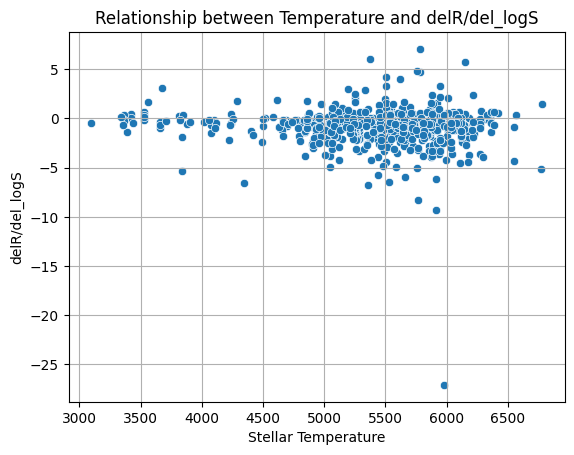

In [ ]:
sns.scatterplot(data=multi_df, x='st_teff', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.grid(True)
plt.show()

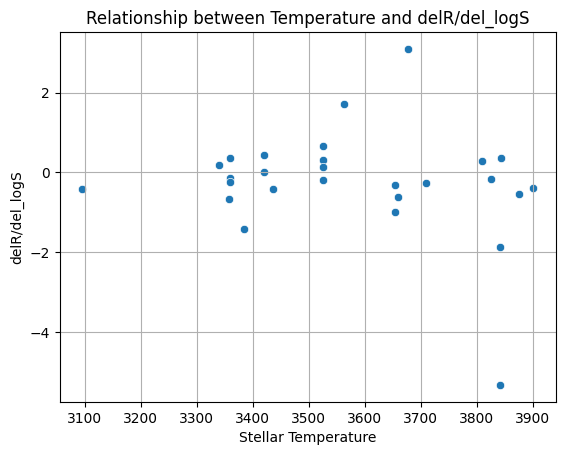

In [ ]:
sns.scatterplot(data=M_df, x='st_teff (K)', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.grid(True)
plt.show()

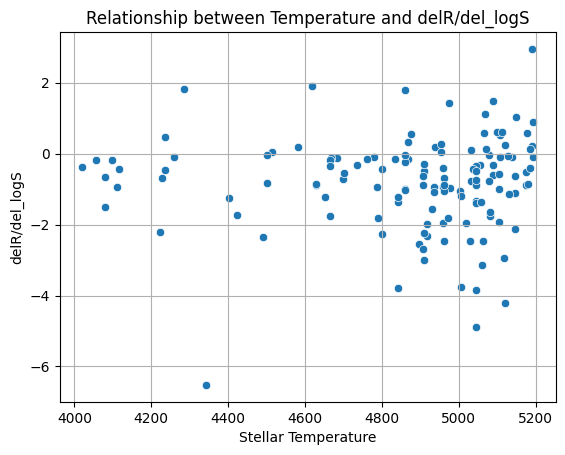

In [ ]:
sns.scatterplot(data=K_df, x='st_teff (K)', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.grid(True)
plt.show()

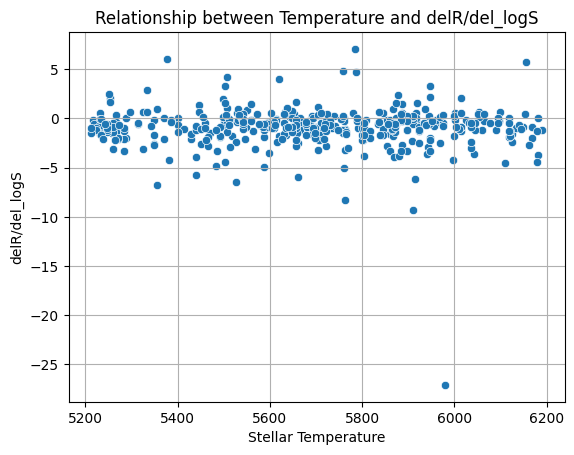

In [ ]:
sns.scatterplot(data=G_df, x='st_teff (K)', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.grid(True)
plt.show()

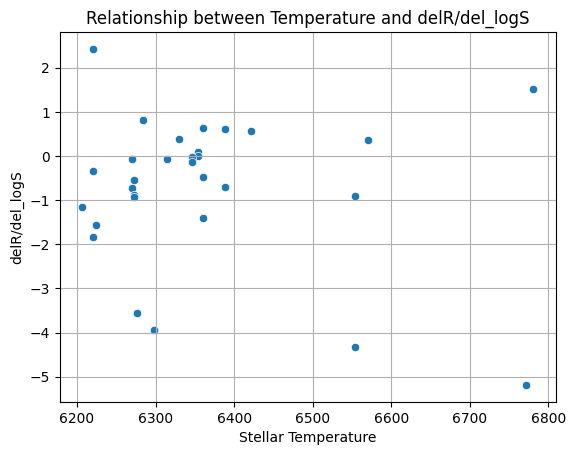

In [ ]:
sns.scatterplot(data=F_df, x='st_teff (K)', y='delR/del_logS')
plt.title('Relationship between Temperature and delR/del_logS')
plt.xlabel('Stellar Temperature')
plt.ylabel('delR/del_logS')
plt.grid(True)
plt.show()

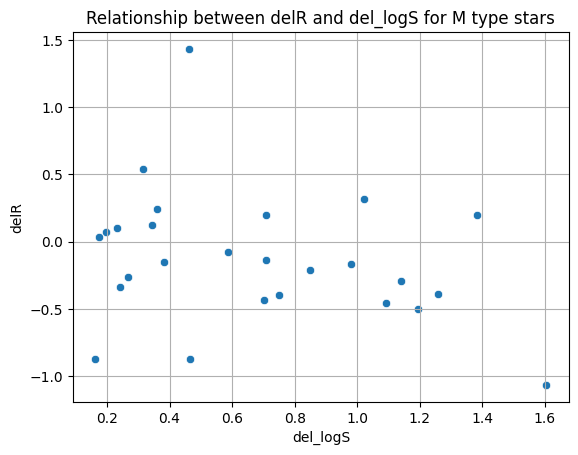

In [ ]:
sns.scatterplot(data=M_df, x='del_logS', y='delR')
plt.title('Relationship between delR and del_logS for M type stars')
plt.xlabel('del_logS')
plt.ylabel('delR')
plt.grid(True)
plt.show()

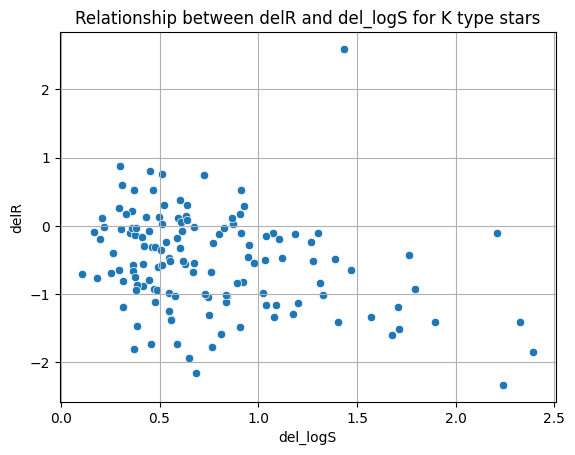

In [ ]:
sns.scatterplot(data=K_df, x='del_logS', y='delR')
plt.title('Relationship between delR and del_logS for K type stars')
plt.xlabel('del_logS')
plt.ylabel('delR')
plt.grid(True)
plt.show()

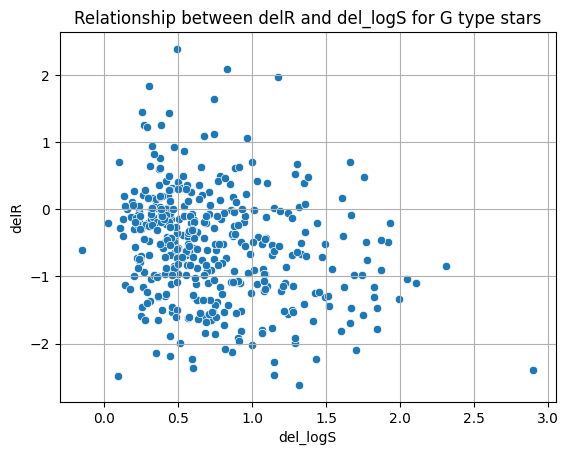

In [ ]:
sns.scatterplot(data=G_df, x='del_logS', y='delR')
plt.title('Relationship between delR and del_logS for G type stars')
plt.xlabel('del_logS')
plt.ylabel('delR')
plt.grid(True)
plt.show()

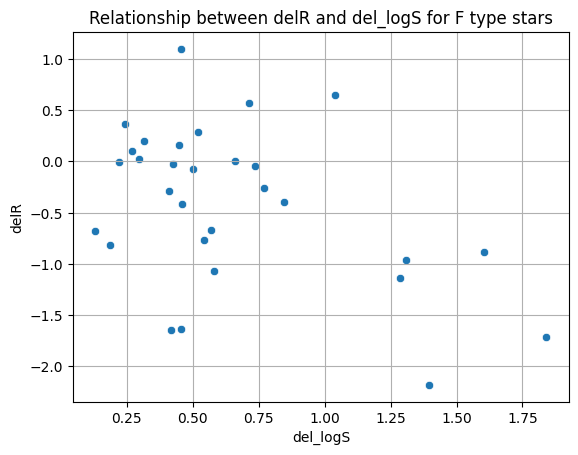

In [ ]:
sns.scatterplot(data=F_df, x='del_logS', y='delR')
plt.title('Relationship between delR and del_logS for F type stars')
plt.xlabel('del_logS')
plt.ylabel('delR')
plt.grid(True)
plt.show()